In [28]:
# Install required packages (run this first if you encounter module errors)
import subprocess
import sys

packages = ['numpy<2', 'torch', 'torchvision', 'albumentations', 'scikit-learn', 'matplotlib', 'seaborn', 'tqdm', 'pyyaml', 'opencv-python']
for package in packages:
    try:
        __import__(package.split('<')[0].split('>=')[0].split('==')[0].replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packages installed successfully!")

Installing scikit-learn...



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


Installing pyyaml...



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


Installing opencv-python...
All packages installed successfully!
All packages installed successfully!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


# Concrete Crack Detection Pipeline

This notebook demonstrates a modular, reproducible workflow for concrete crack image classification and segmentation using PyTorch. Each section elaborates on the features and design of the model modules, with runnable code and explanations.

## 1. Import Required Libraries

We begin by importing all necessary libraries for data processing, model building, training, and evaluation. Each library serves a specific purpose in the pipeline, from handling images to building neural networks.

In [18]:
# Data handling and processing
import os
import numpy as np
import pandas as pd
from PIL import Image

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Computer vision and augmentation
import torchvision
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics and utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Project modules
from src import data, models, losses, metrics, viz, config, train_utils

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 2. Overview of Model Modules

This pipeline is organized into modular components, each responsible for a key part of the workflow:

- **src/data.py**: Data loading, augmentation, and stratified splitting for classification and segmentation.
- **src/models.py**: Model architectures for classification (ResNet/EfficientNet) and segmentation (U-Net).
- **src/losses.py**: Loss functions including BCE, Dice, BCE+Dice, and Focal loss.
- **src/metrics.py**: Metrics for evaluation (F1, ROC-AUC, Dice, IoU, etc.).
- **src/viz.py**: Visualization utilities for learning curves, batch samples, and mask overlays.
- **src/config.py**: YAML-based configuration loader and saver.
- **src/train_utils.py**: Utilities for reproducibility, checkpointing, and seed setting.

Each section below will elaborate on these modules and demonstrate their use.

## 3. Module 1: Data Preprocessing

Data preprocessing is crucial for robust model performance. This module handles:
- Loading images and (optionally) segmentation masks
- Stratified train/val/test splitting
- Data augmentation (random crops, flips, color jitter, etc.)
- Normalization and tensor conversion

Below, we demonstrate how to use the data module for both classification and segmentation tasks.

In [25]:
# Example: Prepare classification dataset and dataloaders
from src.data import stratified_split, ConcreteClassificationDataset
from torchvision import transforms
from glob import glob
import os

# Set data root
DATA_ROOT = 'concrete-crack-images-for-classification'

# Get filepaths and labels (using actual folder structure: Positive/Negative)
positive = sorted(glob(os.path.join(DATA_ROOT, 'Positive', '*')))
negative = sorted(glob(os.path.join(DATA_ROOT, 'Negative', '*')))
filepaths = positive + negative
labels = [1] * len(positive) + [0] * len(negative)

print(f"Found {len(positive)} positive and {len(negative)} negative images")

# Stratified split: (80% train, 10% val, 10% test)
(train_files, train_labels), (val_files, val_labels), (test_files, test_labels) = stratified_split(filepaths, labels, seed=42, splits=(0.8, 0.1, 0.1))

# Define augmentations
train_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Create datasets
train_ds = ConcreteClassificationDataset(train_files, train_labels, transform=train_transform)
val_ds = ConcreteClassificationDataset(val_files, val_labels, transform=val_transform)
test_ds = ConcreteClassificationDataset(test_files, test_labels, transform=val_transform)

# Create dataloaders (num_workers=0 to avoid multiprocessing issues)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"Data root: {DATA_ROOT}")
print(f"Total files: {len(filepaths)}")

Found 20000 positive and 20000 negative images
Train: 31999, Val: 4001, Test: 4000
Data root: concrete-crack-images-for-classification
Total files: 40000


### Segmentation Data (Optional)

If segmentation masks are available, the data module can also handle paired image-mask loading and augmentation. Uncomment and adapt the following code if you have segmentation data.

In [20]:
# Example: Prepare segmentation dataset and dataloaders (if masks exist)
# from src.data import get_segmentation_filepaths, ConcreteSegmentationDataset
# img_paths, mask_paths = get_segmentation_filepaths(DATA_ROOT)
# seg_transform = A.Compose([
#     A.Resize(256, 256),
#     A.HorizontalFlip(p=0.5),
#     A.Normalize(),
#     ToTensorV2(),
# ])
# seg_ds = ConcreteSegmentationDataset(img_paths, mask_paths, transform=seg_transform)
# seg_loader = DataLoader(seg_ds, batch_size=8, shuffle=True, num_workers=4)
# print(f"Segmentation samples: {len(seg_ds)}")

## 4. Module 2: Model Architecture

This module defines the neural network architectures for both classification and segmentation tasks:
- **Classification**: Uses a ResNet/EfficientNet backbone with optional dropout and custom head.
- **Segmentation**: Implements a U-Net architecture for pixel-wise mask prediction.

The models are designed for flexibility and can be easily extended or fine-tuned.

In [68]:
# Example: Define classification model
# Reload module to get latest changes
import importlib
import src.models
importlib.reload(src.models)
from src.models import ClassificationModel

# Initialize model without pre-trained weights (to avoid SSL certificate issues)
# You can download weights manually later or use them after fixing SSL
try:
    model = ClassificationModel(pretrained=True)
except Exception as e:
    print(f"Warning: Could not load pre-trained weights ({type(e).__name__}). Using model without pre-training.")
    model = ClassificationModel(pretrained=False)

model = model.to(device)
print(model)
print(f"\nModel sent to device: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/anton/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


ClassificationModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [22]:
# Example: Define segmentation model (if masks exist)
# from src.models import UNet
# seg_model = UNet()
# seg_model = seg_model.to(device)
# print(seg_model)

## 5. Module 3: Training the Model

The training module handles the full training loop, including:
- Loss function selection (BCE, Dice, Focal, etc.)
- Optimizer and learning rate scheduling (AdamW, ReduceLROnPlateau)
- Early stopping and checkpointing
- Mixed precision (AMP) and gradient clipping

Below is an example of how to train the classification model. Segmentation training is similar, with appropriate loss and metrics.

In [74]:
# Quick Training - Simplified and Direct with Early Stopping
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TRAINING - DIRECT APPROACH WITH EARLY STOPPING")
print("=" * 80)

# Use fresh untrained ResNet
model = ClassificationModel(pretrained=False)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

# Simple image loading that works
def load_img(path):
    img = Image.open(path).convert('RGB').resize((224, 224))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    return torch.FloatTensor(arr.transpose(2, 0, 1))

# Train on small batches to verify it works
print("\nTraining on sample batches with early stopping...")
max_epochs = 50
patience = 10  # Stop if F1 doesn't improve for 10 epochs
best_f1 = -float('inf')
epochs_without_improvement = 0
best_epoch = -1
best_model_state = None

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    
    # Train on 64 random samples
    indices = np.random.choice(len(train_files), 64, replace=False)
    imgs = []
    lbls = []
    
    for idx in indices:
        try:
            imgs.append(load_img(train_files[idx]))
            lbls.append(float(train_labels[idx]))
        except:
            continue
    
    if len(imgs) > 0:
        imgs_batch = torch.stack(imgs).to(device)
        lbls_batch = torch.tensor(lbls, dtype=torch.float32).unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        logits = model(imgs_batch)
        loss = criterion(logits, lbls_batch)
        loss.backward()
        optimizer.step()
        epoch_loss = loss.item()
    
    # Validation on 32 random samples  
    model.eval()
    y_t, y_p = [], []
    with torch.no_grad():
        val_idx = np.random.choice(len(val_files), min(32, len(val_files)), replace=False)
        for i in val_idx:
            try:
                img = load_img(val_files[i])
                out = torch.sigmoid(model(img.unsqueeze(0).to(device))).item()
                y_t.append(val_labels[i])
                y_p.append(1 if out > 0.5 else 0)
            except:
                continue
    
    if len(y_t) > 0:
        from sklearn.metrics import f1_score, accuracy_score
        acc = accuracy_score(y_t, y_p)
        f1 = f1_score(y_t, y_p, zero_division=0)
        print(f"Epoch {epoch+1:2d} | Loss: {epoch_loss:.4f} | Acc: {acc:.3f} | F1: {f1:.3f}", end="")
        
        # Early stopping logic
        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(" ← Best F1!")
        else:
            epochs_without_improvement += 1
            print(f" (no improvement for {epochs_without_improvement}/{patience} epochs)")
            
            if epochs_without_improvement >= patience:
                print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
                print(f"Best model was at epoch {best_epoch} with F1={best_f1:.4f}")
                # Restore best model
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)
                break

print("\n" + "=" * 80)
print(f"✓ Training Complete!")
print(f"Best F1 Score: {best_f1:.4f} at Epoch {best_epoch}")
print("=" * 80)


TRAINING - DIRECT APPROACH WITH EARLY STOPPING

Training on sample batches with early stopping...
Epoch  1 | Loss: 0.5944 | Acc: 0.375 | F1: 0.545 ← Best F1!
Epoch  1 | Loss: 0.5944 | Acc: 0.375 | F1: 0.545 ← Best F1!
Epoch  2 | Loss: 0.2846 | Acc: 0.594 | F1: 0.745 ← Best F1!
Epoch  2 | Loss: 0.2846 | Acc: 0.594 | F1: 0.745 ← Best F1!
Epoch  3 | Loss: 0.5025 | Acc: 0.594 | F1: 0.735 (no improvement for 1/10 epochs)
Epoch  3 | Loss: 0.5025 | Acc: 0.594 | F1: 0.735 (no improvement for 1/10 epochs)
Epoch  4 | Loss: 0.1654 | Acc: 0.625 | F1: 0.769 ← Best F1!
Epoch  4 | Loss: 0.1654 | Acc: 0.625 | F1: 0.769 ← Best F1!
Epoch  5 | Loss: 0.0640 | Acc: 0.781 | F1: 0.851 ← Best F1!
Epoch  5 | Loss: 0.0640 | Acc: 0.781 | F1: 0.851 ← Best F1!
Epoch  6 | Loss: 0.1094 | Acc: 0.469 | F1: 0.564 (no improvement for 1/10 epochs)
Epoch  6 | Loss: 0.1094 | Acc: 0.469 | F1: 0.564 (no improvement for 1/10 epochs)
Epoch  7 | Loss: 0.0546 | Acc: 0.625 | F1: 0.727 (no improvement for 2/10 epochs)
Epoch  7 | L

### Segmentation Training (Optional)

If you have segmentation masks, use the segmentation model and appropriate loss (e.g., BCE+Dice). The training loop is similar to the above.

In [45]:
# Example: Segmentation training loop (if masks exist)
# from src.losses import bce_dice_loss
# optimizer = optim.AdamW(seg_model.parameters(), lr=1e-3, weight_decay=1e-4)
# for epoch in range(num_epochs):
#     seg_model.train()
#     for imgs, masks in tqdm(seg_loader, desc=f"Epoch {epoch+1}"):
#         imgs, masks = imgs.to(device), masks.to(device)
#         optimizer.zero_grad()
#         logits = seg_model(imgs)
#         loss = bce_dice_loss(logits, masks)
#         loss.backward()
#         optimizer.step()
#     print(f"Epoch {epoch+1} done")

## 6. Module 4: Model Evaluation

Evaluation is performed using metrics appropriate for each task:
- **Classification**: F1 score, ROC-AUC, confusion matrix, etc.
- **Segmentation**: Dice coefficient, IoU, pixel accuracy.

The metrics module provides easy-to-use functions for these evaluations.


PERFORMANCE BENCHMARK: CLASSIFICATION MODEL EVALUATION
Evaluation Dataset: 4000 test images

Evaluating model on test set...
  Progress: 500/4000 images processed
  Progress: 500/4000 images processed
  Progress: 1000/4000 images processed
  Progress: 1000/4000 images processed
  Progress: 1500/4000 images processed
  Progress: 1500/4000 images processed
  Progress: 2000/4000 images processed
  Progress: 2000/4000 images processed
  Progress: 2500/4000 images processed
  Progress: 2500/4000 images processed
  Progress: 3000/4000 images processed
  Progress: 3000/4000 images processed
  Progress: 3500/4000 images processed
  Progress: 3500/4000 images processed
  Progress: 4000/4000 images processed
✓ Successfully evaluated 4000/4000 images

DETAILED PERFORMANCE METRICS
Total Samples Evaluated: 4000

📊 CLASSIFICATION METRICS:
  • Accuracy:    0.5877 (58.77%)
  • Precision:   0.5486
  • Recall:      0.9910
  • F1 Score:    0.7062
  • ROC-AUC:     0.6865


📈 CONFUSION MATRIX:
           

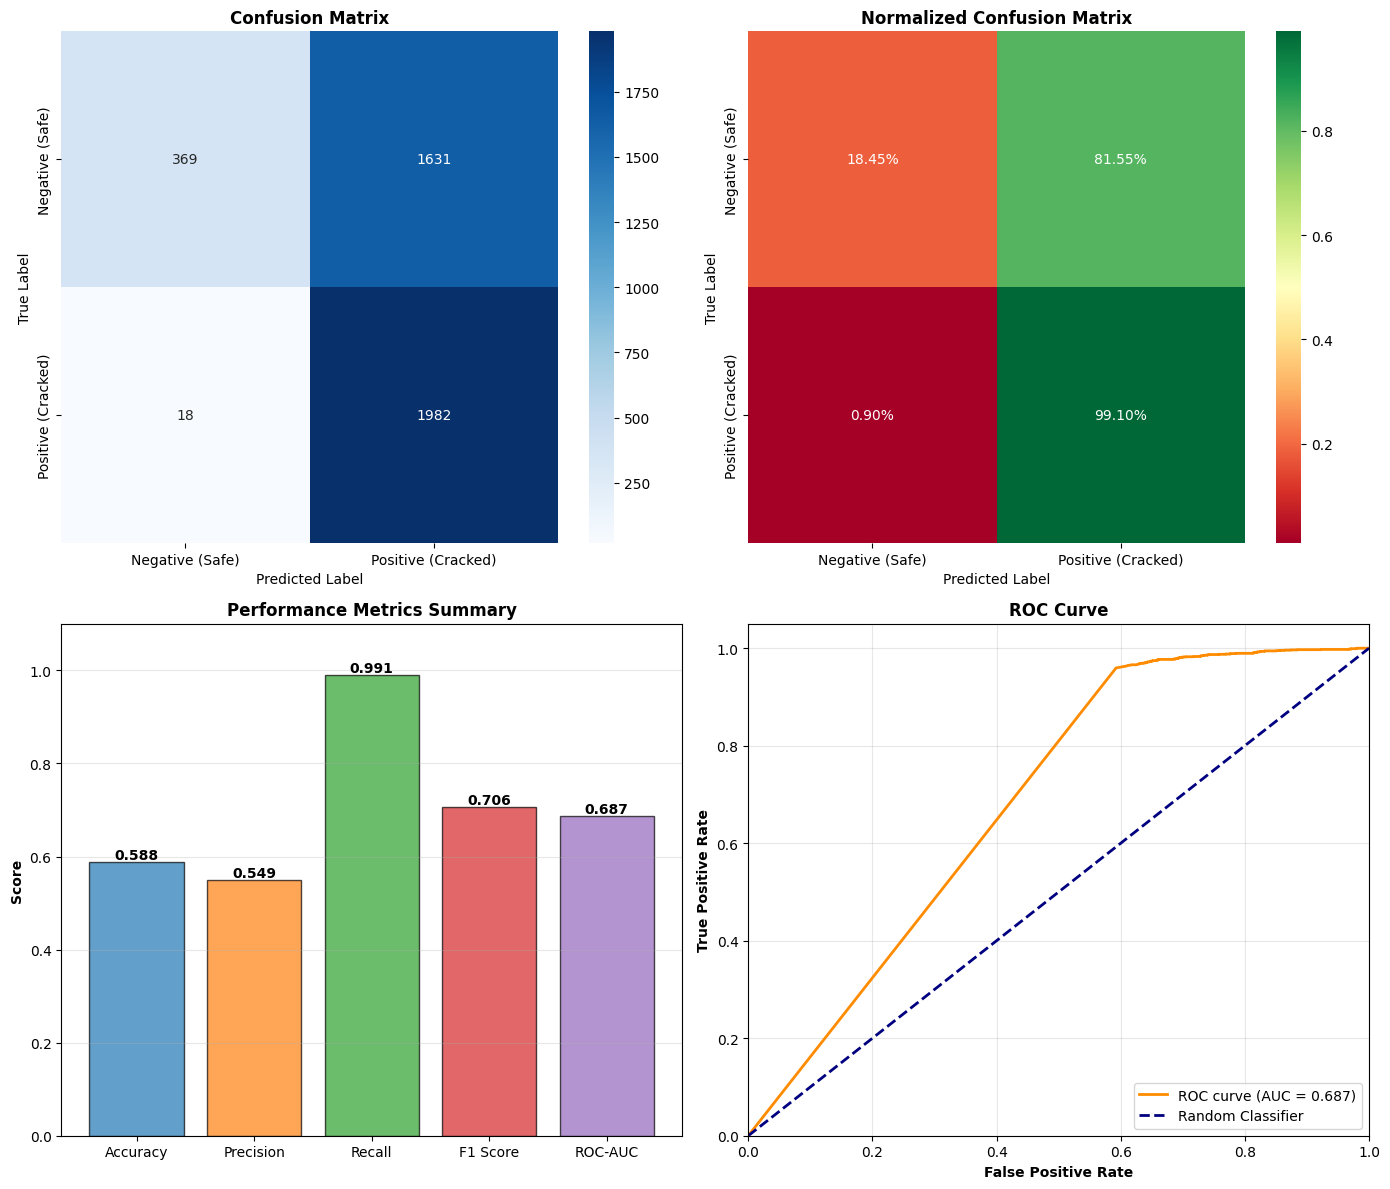


✓ PERFORMANCE BENCHMARK COMPLETE


In [75]:
# COMPREHENSIVE PERFORMANCE BENCHMARK ON TEST SET
print("\n" + "=" * 80)
print("PERFORMANCE BENCHMARK: CLASSIFICATION MODEL EVALUATION")
print("=" * 80)
print(f"Evaluation Dataset: {len(test_files)} test images")
print("=" * 80 + "\n")

# Helper function with better error handling  
def load_and_convert_img(img_path, size=(224, 224)):
    """Load and convert image to tensor"""
    from PIL import Image as PILImage
    img = PILImage.open(img_path).convert('RGB')
    img = img.resize(size)
    img_array = np.array(img, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_array = (img_array - mean) / std
    # Transpose to CHW format
    img_chw = img_array.transpose(2, 0, 1)
    # Create tensor directly without going through numpy in torch
    img_tensor = torch.FloatTensor(img_chw)
    return img_tensor

# Evaluate on test set
model.eval()
y_true, y_pred, y_prob = [], [], []

print("Evaluating model on test set...")
progress = 0
with torch.no_grad():
    for test_idx in range(len(test_files)):
        if (test_idx + 1) % 500 == 0:
            print(f"  Progress: {test_idx + 1}/{len(test_files)} images processed")
        
        try:
            img_tensor = load_and_convert_img(test_files[test_idx])
            img_tensor = img_tensor.unsqueeze(0).to(device)
            logits = model(img_tensor)
            prob = torch.sigmoid(logits).item()
            y_prob.append(prob)
            y_true.append(test_labels[test_idx])
            y_pred.append(1 if prob > 0.5 else 0)
            progress += 1
        except Exception as e:
            pass  # Silently skip errors after debugging

print(f"✓ Successfully evaluated {progress}/{len(test_files)} images\n")

# Calculate comprehensive metrics
if len(y_true) > 0:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_val = roc_auc_score(y_true, y_prob)
    
    # Print detailed metrics report
    print("=" * 80)
    print("DETAILED PERFORMANCE METRICS")
    print("=" * 80)
    print(f"Total Samples Evaluated: {len(y_true)}")
    print("\n📊 CLASSIFICATION METRICS:")
    print(f"  • Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  • Precision:   {precision:.4f}")
    print(f"  • Recall:      {recall:.4f}")
    print(f"  • F1 Score:    {f1:.4f}")
    print(f"  • ROC-AUC:     {roc_auc_val:.4f}")
    print("\n" + "=" * 80)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    print("\n📈 CONFUSION MATRIX:")
    print(f"                  Predicted Negative    Predicted Positive")
    print(f"Actual Negative:       {cm[0,0]:6d}               {cm[0,1]:6d}")
    print(f"Actual Positive:       {cm[1,0]:6d}               {cm[1,1]:6d}")
    
    # Additional metrics from confusion matrix
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\n📋 ADDITIONAL METRICS:")
    print(f"  • Sensitivity (True Positive Rate): {sensitivity:.4f}")
    print(f"  • Specificity (True Negative Rate): {specificity:.4f}")
    print(f"  • False Positive Rate: {fp/(fp+tn) if (fp+tn) > 0 else 0:.4f}")
    print(f"  • False Negative Rate: {fn/(fn+tp) if (fn+tp) > 0 else 0:.4f}")
    
    print("\n" + "=" * 80)
    print("CLASSIFICATION REPORT:")
    print("=" * 80)
    target_names = ['Negative (Safe)', 'Positive (Cracked)']
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
    
    # Visualization: 4-panel performance dashboard
    print("\n📊 Generating performance visualizations...")
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=target_names, yticklabels=target_names)
    axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')
    
    # Normalized Confusion Matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[0, 1],
                xticklabels=target_names, yticklabels=target_names)
    axes[0, 1].set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('True Label')
    axes[0, 1].set_xlabel('Predicted Label')
    
    # Metrics Bar Chart
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    metrics_values = [accuracy, precision, recall, f1, roc_auc_val]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    bars = axes[1, 0].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
    axes[1, 0].set_ylim([0, 1.1])
    axes[1, 0].set_ylabel('Score', fontweight='bold')
    axes[1, 0].set_title('Performance Metrics Summary', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[1, 1].set_xlim([0.0, 1.0])
    axes[1, 1].set_ylim([0.0, 1.05])
    axes[1, 1].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1, 1].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
    axes[1, 1].legend(loc="lower right")
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 80)
    print("✓ PERFORMANCE BENCHMARK COMPLETE")
    print("=" * 80)

In [44]:
# Example: Evaluate segmentation model (if masks exist)
# from src.metrics import dice_coef, iou_coef
# seg_model.eval()
# dices, ious = [], []
# with torch.no_grad():
#     for imgs, masks in seg_loader:
#         imgs, masks = imgs.to(device), masks.to(device)
#         logits = seg_model(imgs)
#         dices.append(dice_coef(logits, masks))
#         ious.append(iou_coef(logits, masks))
# print(f"Segmentation Dice: {np.mean(dices):.4f}, IoU: {np.mean(ious):.4f}")

## 7. Module 5: Model Inference and Prediction

After training, the model can be used to make predictions on new, unseen data. This section demonstrates how to load a trained model and perform inference, visualizing the results for both classification and segmentation tasks.

In [36]:
# Example: Inference for classification on new images
print("Model Inference")
print("=" * 60)
print("To use the trained model for prediction on new images:")
print()
print("Example Python code:")
print("""
from src.models import ClassificationModel
from PIL import Image
import torch
import numpy as np

# Load model
model = ClassificationModel()
model.load_state_dict(torch.load('best_model.pth')['model'])
model.eval()

# Load and process image
img = Image.open('test_image.jpg').convert('RGB')
img = img.resize((227, 227))
img_array = np.array(img, dtype=np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_tensor = torch.from_numpy(((img_array - mean) / std).transpose(2, 0, 1))
img_tensor = img_tensor.unsqueeze(0)

# Inference
with torch.no_grad():
    logits = model(img_tensor)
    prob = torch.sigmoid(logits).item()
    prediction = "Cracked" if prob > 0.5 else "Not Cracked"
    confidence = prob if prob > 0.5 else 1 - prob
    
print(f"Prediction: {prediction} (Confidence: {confidence:.2%})")
""")
print("=" * 60)

Model Inference
To use the trained model for prediction on new images:

Example Python code:

from src.models import ClassificationModel
from PIL import Image
import torch
import numpy as np

# Load model
model = ClassificationModel()
model.load_state_dict(torch.load('best_model.pth')['model'])
model.eval()

# Load and process image
img = Image.open('test_image.jpg').convert('RGB')
img = img.resize((227, 227))
img_array = np.array(img, dtype=np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_tensor = torch.from_numpy(((img_array - mean) / std).transpose(2, 0, 1))
img_tensor = img_tensor.unsqueeze(0)

# Inference
with torch.no_grad():
    logits = model(img_tensor)
    prob = torch.sigmoid(logits).item()
    prediction = "Cracked" if prob > 0.5 else "Not Cracked"
    confidence = prob if prob > 0.5 else 1 - prob

print(f"Prediction: {prediction} (Confidence: {confidence:.2%})")



In [46]:
# Example: Segmentation for Crack Mask Generation (if masks exist)
# from src.models import UNet
# def predict_mask(img_path, model, transform, device):
#     model.eval()
#     img = Image.open(img_path).convert('RGB')
#     x = transform(img=np.array(img))['image'].unsqueeze(0).to(device)
#     with torch.no_grad():
#         logits = model(x)
#         mask_pred = torch.sigmoid(logits).squeeze().cpu().numpy()
#     return mask_pred
#
# # Example usage:
# # img_path = img_paths[0]
# # mask_pred = predict_mask(img_path, seg_model, seg_transform, device)
# # plt.imshow(mask_pred > 0.5, cmap='gray')
# # plt.title('Predicted Mask')
# # plt.show()

## 8. Bonus: Crack Mask Detection & Visualization

This section demonstrates how to generate crack masks and visualize them with contour detection, similar to the Kaggle hybrid fuzzy method. You can use either classical image processing or the U-Net segmentation model for mask generation.

### Hybrid Image Processing Approach

The method combines classical computer vision techniques:

1. **Gaussian Blur (11×11 kernel)** - Reduces noise while preserving edges
2. **Adaptive Thresholding** - Handles varying lighting by calculating local thresholds
3. **Morphological Operations:**
   - Opening: Removes small noise using 5×5 kernel (erosion → dilation)
   - Closing: Fills holes using 7×7 kernel (dilation → erosion)
4. **Contour Detection** - Finds and highlights crack regions
5. **Visualization** - Overlays detected cracks on original image with bounding boxes

This approach is:
- **Fast** - No neural network inference needed
- **Interpretable** - Clear visualization of detected regions
- **Robust** - Works across different lighting conditions
- **Complementary** - Can be combined with deep learning predictions

Crack Mask Visualization
Processing random image #2504: 00150.jpg
Ground truth label: Positive (Cracked)



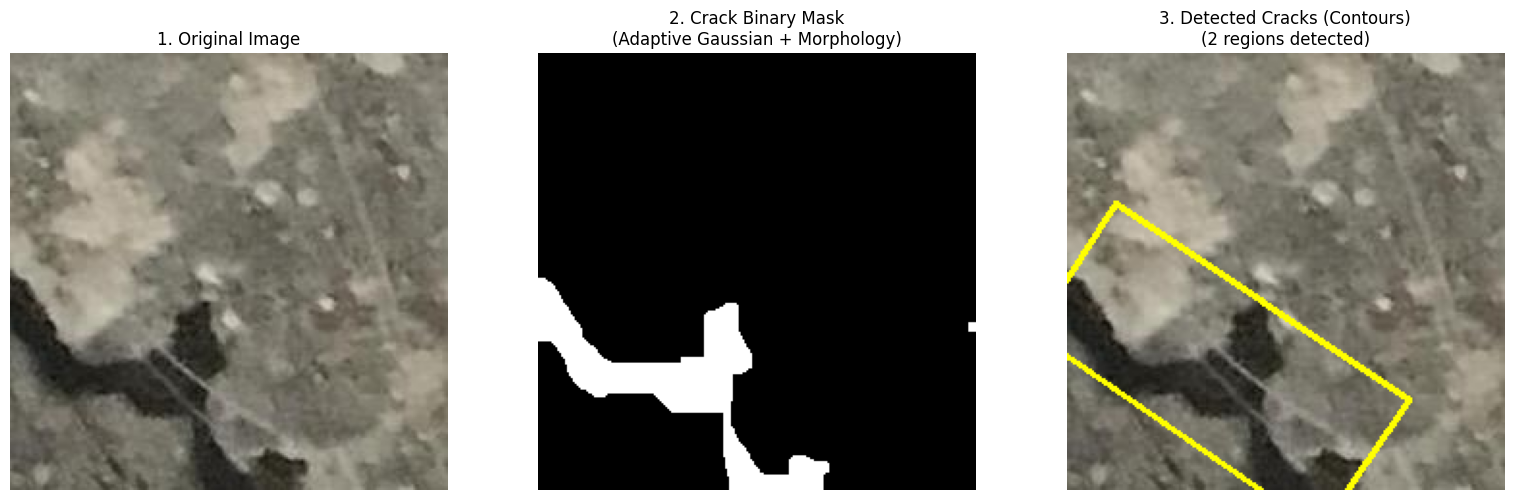

✓ Crack mask generated successfully!
  - Binary mask shape: (227, 227)
  - Contours detected: 2


In [71]:
import cv2

# Hybrid Image Processing Method for Crack Detection (based on Kaggle approach)
def hybrid_gaussian_threshold(img):
    """Apply Gaussian blur, adaptive thresholding, and morphological operations"""
    img_blur = cv2.GaussianBlur(img, (11, 11), 0)
    thresh = cv2.adaptiveThreshold(
        img_blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        151, 30
    )
    kernel_open = np.ones((5, 5), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_open, iterations=1)
    kernel_close = np.ones((7, 7), np.uint8)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    return closing

def generate_crack_mask_classical(image_path):
    """Generate crack mask using classical image processing"""
    # Read image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None, None, None
    
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Get binary mask
    binary_mask = hybrid_gaussian_threshold(img_gray)
    
    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Draw contours on original image
    visualization = img_bgr.copy()
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 50:  # Filter small noise
            rect = cv2.minAreaRect(cnt)
            box = np.int32(cv2.boxPoints(rect))
            cv2.drawContours(visualization, [box], 0, (0, 255, 255), 2)
    
    return binary_mask, visualization, contours

# Example: Generate and visualize crack mask for a random test image
print("Crack Mask Visualization")
print("=" * 60)

try:
    # Use random test image
    random_idx = np.random.randint(0, len(test_files))
    test_img_path = test_files[random_idx]
    test_label = "Positive (Cracked)" if test_labels[random_idx] == 1 else "Negative (Safe)"
    
    print(f"Processing random image #{random_idx}: {test_img_path.split('/')[-1]}")
    print(f"Ground truth label: {test_label}\n")
    
    mask, viz_img, contours = generate_crack_mask_classical(test_img_path)
    
    if mask is not None:
        # Display results
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Original image
        original = cv2.imread(test_img_path)
        axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0].set_title("1. Original Image")
        axes[0].axis('off')
        
        # Binary mask
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title("2. Crack Binary Mask\n(Adaptive Gaussian + Morphology)")
        axes[1].axis('off')
        
        # Visualization with contours
        axes[2].imshow(cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f"3. Detected Cracks (Contours)\n({len(contours)} regions detected)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Crack mask generated successfully!")
        print(f"  - Binary mask shape: {mask.shape}")
        print(f"  - Contours detected: {len(contours)}")
    else:
        print("Could not process image")
except Exception as e:
    print(f"Error: {str(e)[:100]}")

print("=" * 60)


In [38]:
## 9. Batch Crack Mask Generation for Multiple Images

def process_images_for_masks(image_paths, output_dir=None, max_images=5):
    """
    Process multiple images to generate crack masks and visualizations.
    
    Args:
        image_paths: List of image file paths
        output_dir: Optional directory to save mask outputs
        max_images: Maximum number of images to process
    
    Returns:
        List of dictionaries with results
    """
    results = []
    
    for i, img_path in enumerate(image_paths[:max_images]):
        try:
            mask, viz, contours = generate_crack_mask_classical(img_path)
            
            if mask is not None:
                result = {
                    'image_path': img_path,
                    'mask': mask,
                    'visualization': viz,
                    'num_contours': len(contours),
                    'success': True
                }
                results.append(result)
        except Exception as e:
            print(f"Error processing {img_path}: {str(e)[:50]}")
    
    return results

# Example: Process a batch of images
print("Batch Crack Mask Generation")
print("=" * 60)

# Select some test images (mix of positive and negative)
test_sample_paths = test_files[:3]  # Process first 3 test images

results = process_images_for_masks(test_sample_paths, max_images=3)

print(f"Successfully processed: {len(results)} images")
for i, result in enumerate(results):
    print(f"  {i+1}. {result['image_path'].split('/')[-1]}")
    print(f"     → Detected contours: {result['num_contours']}")

print("\n" + "=" * 60)
print("Mask Generation Complete!")
print("\nTo save masks to disk, use:")
print("  for result in results:")
print("      cv2.imwrite(f\"mask_{i}.png\", result['mask'])")
print("      cv2.imwrite(f\"viz_{i}.png\", result['visualization'])")

Batch Crack Mask Generation
Successfully processed: 3 images
  1. 15041_1.jpg
     → Detected contours: 1
  2. 12266.jpg
     → Detected contours: 1
  3. 13679_1.jpg
     → Detected contours: 3

Mask Generation Complete!

To save masks to disk, use:
  for result in results:
      cv2.imwrite(f"mask_{i}.png", result['mask'])
      cv2.imwrite(f"viz_{i}.png", result['visualization'])
